# Recreating NeRF
This is a PyTorch implementation based on the paper: https://arxiv.org/abs/2003.08934.

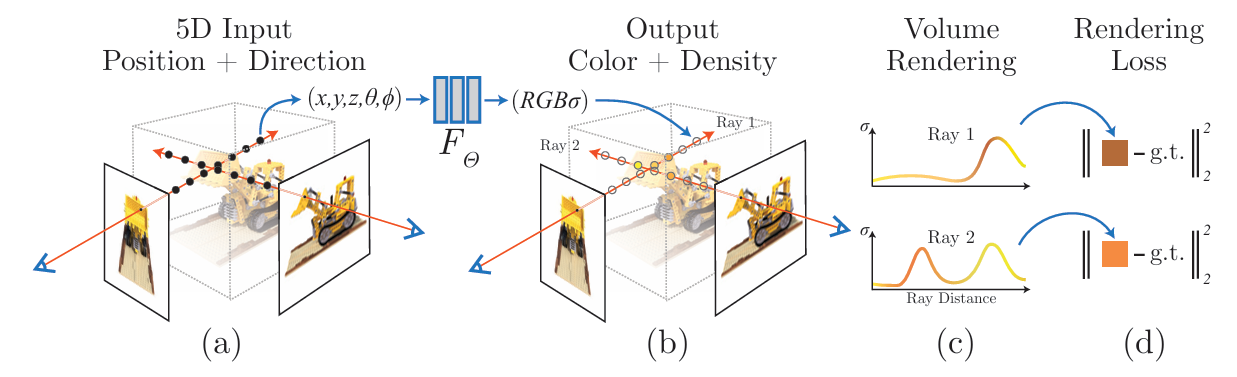

## Imports + Data


In [18]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
import time
from ipywidgets import interactive, widgets

['images', 'poses', 'focal']
Images shape: (106, 100, 100, 3)
Poses shape: (106, 4, 4)
Focal length: 138.88887889922103
Images dtype: float32
Poses dtype: float32
Focal dtype: <class 'numpy.ndarray'>
[[-9.9990219e-01  4.1922452e-03 -1.3345719e-02 -5.3798322e-02]
 [-1.3988681e-02 -2.9965907e-01  9.5394367e-01  3.8454704e+00]
 [-4.6566129e-10  9.5403719e-01  2.9968831e-01  1.2080823e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  1.0000000e+00]]


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

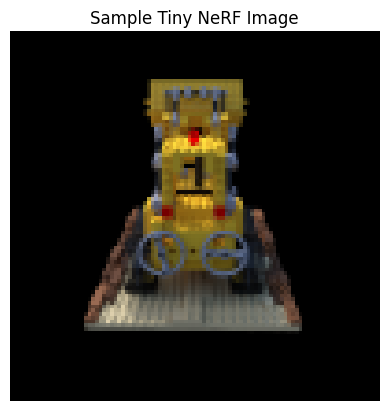

In [19]:
# data
file_name = 'tiny_nerf_data.npz'
if not os.path.exists(file_name):
    !wget --no-check-certificate http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

# Loading the data once downloaded
data_load = np.load(file_name)

# printing info about data
print(data_load.files)
print("Images shape:", data_load['images'].shape)
print("Poses shape:", data_load['poses'].shape)
print("Focal length:", data_load['focal'])
print("Images dtype:", data_load['images'].dtype)
print("Poses dtype:", data_load['poses'].dtype)
print("Focal dtype:", type(data_load['focal']))
poses = data_load['poses']
print(poses[0])

#just looking one image
images = data_load['images']
plt.imshow(images[0])
plt.title("Sample Tiny NeRF Image")
plt.axis("off")


## Encoding + Model

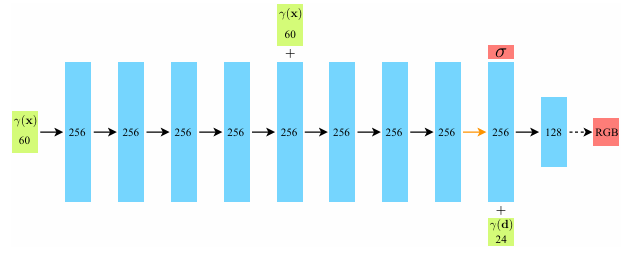

- Core Volume Rendering Variables:
    - x = (x, y, z) → 3D position in space
    - d = viewing direction
    - σ (sigma) → density of matter at that point
    - RGB → color of light coming from that point

- Positional Encoding ($\gamma$): This acts like a magnifying glass. By transforming $(x,y,z)$ into 60 different sine/cosine values, we are "stretching" the data so the network can see tiny differences in position.
    - $$\gamma(p) = (\sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p))$$
    - For 3D positions ($x, y, z$): The authors use $L = 10$. Since there are three coordinates and each is transformed into $2 \times 10 = 20$ values, the total encoded position becomes a 60-dimensional vector.
    - For viewing direction ($d$): The authors use $L = 4$. This transforms the 3D direction vector into a 24-dimensional vector ($3 \times 2 \times 4$)

- 8 fully-connected layers. Each of these layers contains 256 channels and uses a ReLU activation function.
- Combined Input to Layer 5: $256 + 60 = 316$ values (skip connection to not forget)
- After 8th Layer:
    - network immediately outputs $\sigma$ (Volume Density).This is just a single number representing how "solid" or opaque the space is at that exact $(x, y, z)$ coordinate.
    - Along with the density, the 8th layer also outputs that 256-dimensional feature vector we talked about earlier. This is the "summary" of the point's material properties.
    - The network takes the 256-dimensional summary. It concatenates it with the 24-dimensional encoded viewing direction ($256 + 24 = 280$ values).
    - This 280-number list is fed into smaller layer of 128 neurons (which acts as a specialized "color calculator").
    - final Output 3 numbers: R, G, and B.

In [20]:
def encoding(x, L=10):
    out = [x]
    for i in range(L):
        out.append(torch.sin(2**i * torch.pi * x))
        out.append(torch.cos(2**i *torch.pi* x))
    return torch.cat(out, dim=-1)

class NeRF(nn.Module):
    def __init__(self, pos_enc_dim=63, view_enc_dim=27, hidd_layer=256) ->None:
        super().__init__()

        # First layer
        self.linear1 = nn.Linear(pos_enc_dim, hidd_layer)

        # 4 layers before skip connection
        self.pre1 = nn.Linear(hidd_layer, hidd_layer)
        self.pre2 = nn.Linear(hidd_layer, hidd_layer)
        self.pre3 = nn.Linear(hidd_layer, hidd_layer)
        self.pre4 = nn.Linear(hidd_layer, hidd_layer)

        # Skip connection layer
        self.linear_skip = nn.Linear(pos_enc_dim + hidd_layer, hidd_layer)

        # 2 layers after skip
        self.post1 = nn.Linear(hidd_layer, hidd_layer)
        self.post2 = nn.Linear(hidd_layer, hidd_layer)

        # Density output
        self.density_layer = nn.Linear(hidd_layer, 1)

        # Feature layer
        self.linear2 = nn.Linear(hidd_layer, hidd_layer)

        # Color layers
        self.color1 = nn.Linear(hidd_layer + view_enc_dim, hidd_layer // 2)
        self.color2 = nn.Linear(hidd_layer // 2, 3)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input):
        # Split position and view direction
        positions = input[..., :3]
        view_dirs = input[..., 3:]

        # Positional encoding
        pos_enc = encoding(positions, L=10)
        view_enc = encoding(view_dirs, L=4)

        # First layer
        x = self.relu(self.linear1(pos_enc))

        # 4 layers
        x = self.relu(self.pre1(x))
        x = self.relu(self.pre2(x))
        x = self.relu(self.pre3(x))
        x = self.relu(self.pre4(x))

        # Skip connection
        x = torch.cat([x, pos_enc], dim=-1)
        x = self.relu(self.linear_skip(x))

        # Post skip layers
        x = self.relu(self.post1(x))
        x = self.relu(self.post2(x))

        # Density
        sigma = self.relu(self.density_layer(x))

        # Feature
        x = self.linear2(x)

        # Add viewing direction
        x = torch.cat([x, view_enc], dim=-1)

        # Color prediction
        x = self.relu(self.color1(x))
        rgb = self.sigmoid(self.color2(x))

        return torch.cat([sigma, rgb], dim=-1)

## Get Ray

- The NeRF neural network (the MLP) requires a continuous 3D coordinate $(x, y, z)$ and a 3D viewing direction $d$ as its inputs. So, march camera rays through the scene to generate a sampled set of 3D points
- A single ray in 3D space is defined by the equation:$$\mathbf{r}(t) = \mathbf{o} + t\mathbf{d}$$
    - $\mathbf{o}$ is the ray origin (the 3D coordinate of the camera lens).
    - $\mathbf{d}$ is the ray direction (the 3D vector pointing from the lens through a specific pixel).
    - $t$ is the distance along the ray (depth).
     
- The 3D direction vector $\mathbf{d}_{camera} = (X_c, Y_c, Z_c)$ for a pixel $(u, v)$ is calculated as:
    - Let the focal length be $f$.
    - Let the center of the image be $(c_x, c_y)$ which is $(W/2, H/2)$.
    - $X_c = \frac{u - c_x}{f}$ (Shift pixel to the center, scale by focal length)
    - $Y_c = -\frac{v - c_y}{f}$ (Shift to center, scale by focal length. The negative sign flips the Y-axis because image coordinates go down, but standard 3D coordinates go up).
    - $Z_c = -1$ (The image plane is projected 1 unit away on the negative Z-axis).

- A Camera-to-World (c2w) matrix is a $4 \times 4$ mathematical matrix that defines the camera's pose:$$\text{c2w} = \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \\ 0 & 0 & 0 & 1 \end{bmatrix}$$
    - The top-left $3 \times 3$ block is the Rotation Matrix ($R$), which defines the camera's tilt and pan.
    - The top-right $3 \times 1$ column is the Translation Vector ($\mathbf{t}$), which defines the physical $(X,Y,Z)$ location of the camera.

In [21]:
def get_rays(H, W, focal, c2w):
    """
    Generate rays for a given camera configuration.

    Args:
        H: Image height.
        W: Image width.
        focal: Focal length.
        c2w: Camera-to-world transformation matrix (4x4).

    Returns:
        rays_o: Ray origins (H*W, 3).
        rays_d: Ray directions (H*W, 3).
    """
    # Convert focal length to tensor and move to same device
    focal = torch.tensor(focal, dtype=torch.float32, device=c2w.device)

    # 1. Create grid of pixel coordinates
    xs = torch.arange(W, dtype=torch.float32, device=c2w.device)
    ys = torch.arange(H, dtype=torch.float32, device=c2w.device)

    i, j = torch.meshgrid(xs, ys, indexing='xy')

    # 2. Convert pixels to camera ray directions
    x = (i - W/2) / focal
    y = -(j - H/2) / focal
    z = -torch.ones_like(i)

    dirs = torch.stack([x, y, z], dim=-1)

    # 3. Rotate rays from camera space → world space
    rays_d = torch.matmul(dirs, c2w[:3, :3].T)

    # 4️. Every ray starts from camera position
    rays_o = c2w[:3, 3].expand(rays_d.shape)

    # 5️. Flatten (H,W,3) → (H*W,3)
    rays_d = rays_d.reshape(-1,3)
    rays_o = rays_o.reshape(-1,3)

    return rays_o, rays_d

## Volume Render

- To approximate the continuous integral, the space between the near ($t_n$) and far ($t_f$) bounds is divided into $N$ evenly spaced bins
- Now that we have $N$ specific 3D coordinates along the ray, we ask the Multilayer Perceptron (MLP) for the properties of the matter at those exact locations.
    - $$F_\Theta(\mathbf{x}, \mathbf{d}) \rightarrow (\mathbf{c}, \sigma)$$
    - $\mathbf{x}$ = The 3D coordinate $(X, Y, Z)$
    - $\mathbf{d}$ = The viewing direction
    - $\sigma$ = Volume Density (how "solid" the point is)
    - $\mathbf{c}$ = RGB Color (the light emitted from that point)

- The physical distance between the current sample point and the next sample point.$$\delta_i = t_{i+1} - t_i$$
- The probability that the ray of light hits a particle and terminates within this specific segment $\delta_i$. If density ($\sigma$) is high, $\alpha \rightarrow 1$ (opaque). If density is zero, $\alpha = 0$ (transparent empty space).$$\alpha_i = 1 - \exp(-\sigma_i \delta_i)$$
- The probability that light travels from the camera to point $i$ without hitting anything else first. It is the cumulative product of transparency $(1 - \alpha)$ of all previous points. If a solid object ($\alpha=1$) is in front of point $i$, transmittance becomes $0$, meaning point $i$ is blocked (occluded).(T1=1)$$T_i = \prod_{j<i} (1 - \alpha_j)$$
- Finally, we squash the 3D ray down into a single 2D pixel color.
    - First, we calculate the weight ($w_i$) of each point. A point only contributes to the final image if it is solid ($\alpha_i$ is high) AND it is not blocked by something in front of it ($T_i$ is high):$$w_i = T_i \alpha_i$$
    - Then, we compute the final estimated color $\hat{C}(\mathbf{r})$ of the camera ray by summing the weighted colors of all $N$ samples. This is the Discrete Volume Rendering Equation:$$\hat{C}(\mathbf{r}) = \sum_{i=1}^{N} w_i \mathbf{c}_i$$

In [22]:
def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, device, rand=False):
    """
    Render pixel colors for a batch of rays using the NeRF network.

    Parameters:
        network_fn : neural network
            NeRF model that predicts (density, RGB)

        rays_o : tensor (N_rays, 3)
            Ray origins (camera positions)

        rays_d : tensor (N_rays, 3)
            Ray directions

        near, far : float
            Minimum and maximum distance to sample along the ray

        N_samples : int
            Number of sample points along each ray

        device : torch device

    Returns:
        rgb_map   : (N_rays,3) predicted pixel colors
        depth_map : (N_rays)   expected depth
        acc_map   : (N_rays)   accumulated opacity
    """
    def batchify(fn, chunk):
        return lambda inputs: torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)
    chunk = 1024 * 4

    # 1. Sample points along each ray
    ## Create evenly spaced depth values between near and far
    # 1. Sample points along each ray
    z_vals = torch.linspace(near, far, N_samples, device=device)

    # NEW: Add random jitter to z_vals if rand=True
    if rand:
        # Generate random noise between 0 and the size of one bin
        z_vals += torch.rand(*z_vals.shape[:-1], N_samples, device=rays_o.device) * (far - near) / N_samples

    ## Compute 3D points along each ray r(t) = origin + direction * distance
    ## none here adds new axis
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]# Shape -> (N_rays,N_samples, 3)


    # 2. Prepare viewing directions
    ## Normalize ray directions
    view_dirs = rays_d / torch.norm(rays_d, dim=-1, keepdim=True) # view_dirs = (N_rays,3)
    ## Repeat view direction for every sample point becuase viewing direction will be same for every sample point in ray
    view_dirs = view_dirs[..., None, :].expand(pts.shape)# Shape -> (N_rays, N_samples, 3)
    ## Combine position + viewing direction
    inputs = torch.cat([pts, view_dirs], dim=-1) # Shape -> (N_rays, N_samples, 6)


    # 3. Query NeRF network (with batching)
    ## flatten samples
    # inputs_flat = inputs.reshape(-1, inputs.shape[-1])  # (N_rays*N_samples, 6)
    ## batchify network evaluation
    raw = batchify(network_fn, chunk)(inputs)
    # reshape back
    # raw = raw_flat.reshape(inputs.shape[0], inputs.shape[1], 4)
    ## Network output for each point: [ sigma , R , G , B ]
    ## raw[...,0] -> density
    ## raw[...,1:] -> RGB color
    sigma = raw[..., 0]     # density (N_rays, N_samples)
    rgb = raw[..., 1:]      # color   (N_rays, N_samples, 3)


    # 4. Compute distances between sample points
    dists = z_vals[..., 1:] - z_vals[..., :-1]
    ## Add large distance for the last sample we assume last point is very far so dist also very large
    dists = torch.cat([dists, torch.tensor([1e10], device=device)], dim=-1)
    ## Expand for all rays
    # dists = dists.unsqueeze(0) #(1 , N_samples)

    # 5. Convert density → opacity (alpha)
    ## α = 1 − exp(−σ δ)
    ## PyTorch broadcasting internally expands dists to match sigma.
    alpha = 1. - torch.exp(-sigma * dists)  # Shape: [batch, N_samples]
    alpha = alpha.unsqueeze(-1)  # Shape: [batch, N_samples, 1]

    # 6. Compute transmittance
    ## T_i = probability that ray reaches sample i
    ## comprod coputes comulative product
    ## T1 = 1
    ## T2 = (1-α1)
    ## T3 = (1-α1)(1-α2) so removing last term from cumprod
    ones_shape = (alpha.shape[0], 1, 1)
    T = torch.cumprod(
        torch.cat([torch.ones(ones_shape, device=device), 1 - alpha + 1e-10], dim=1),
        dim=1)[:, :-1]   # Shape: [batch, N_samples, 1]

    # 7. Compute rendering weights
    weights = alpha * T  # Shape: [batch, N_samples, 1]

    # 8. Compute final pixel color summing along sample dimension
    # weights → (N_rays, N_samples, 1) broadcasting will expand it to rgb shape
    # rgb     → (N_rays, N_samples, 3)
    rgb_map = torch.sum(weights * rgb, dim=1) #(N_rays, 3)

    # 9️. Compute depth map
    ## squeeze(-1) removes last dimension so (N_rays, N_samples)
    ## multiplication results (N_rays, N_samples)
    depth_map = torch.sum(weights.squeeze(-1) * z_vals, dim=1) # shape (N_rays)

    # 10. Compute accumulated opacity
    acc_map = torch.sum(weights.squeeze(-1), dim=1) # (N_rays)

    return rgb_map, depth_map, acc_map

## Train Loop

- NeRF trains by minimizing pixel reconstruction error.
    - Loss:$$L(\theta) = \frac{1}{N} \sum_{r \in R} \left\| C_\theta(r) - C_{gt}(r) \right\|^2$$
    - $C_\theta(r)$ = predicted color
    - $C_{gt}(r)$ = ground truth pixel color

- Adam updates parameters using gradient descent:$$\theta_{t+1} = \theta_t - \eta \nabla_\theta L$$
- Learning rate decays:$$lr_t = lr_0 \times \gamma^t$$
- Peak Signal-to-Noise Ratio (PSNR):$$PSNR = -10 \log_{10}(MSE)$$

In [23]:
def train(images, poses, H, W, focal, test_pose, test_img, device):

    print("Using device:", device)

    # 1. Create NeRF model
    model = NeRF().to(device)

    # 2. Loss function and optimizer
    loss_fn = nn.MSELoss(reduction="mean")
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    # Exponential decay to carefully lower the learning rate over time
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

    # Training settings
    num_iterations = 1000
    num_samples = 64
    print_every = 50
    psnrs=[]
    iternums = []

    # Convert dataset to tensors
    images = torch.from_numpy(images).float().to(device)
    poses = torch.from_numpy(poses).float().to(device)
    test_img = test_img.to(device)
    test_pose = test_pose.to(device)

    for step in range(num_iterations):
        t0 = time.time()

        # 3. Pick a random training image
        img_index = np.random.randint(images.shape[0])
        target_img = images[img_index]
        pose = poses[img_index]

        # 4. Generate camera rays for this image
        rays_o, rays_d = get_rays(H, W, focal, pose)

        optimizer.zero_grad()

        # 5. Render predicted image using NeRF
        rgb, depth, acc = render_rays(
            model,
            rays_o,
            rays_d,
            near=2.0,
            far=6.0,
            N_samples=num_samples,
            device=device,
            rand=True
        )


        # Convert rays back to image shape
        rgb = rgb.reshape(H, W, 3)

        # 6. Compute loss
        loss = loss_fn(rgb, target_img)


        # 7. Backpropagation
        loss.backward()
        optimizer.step()

        # 8. Visualization
        if step % print_every == 0:

            print(f"Step {step} | Loss: {loss.item():.6f}")

            with torch.no_grad():
                # Render from test camera
                rays_o, rays_d = get_rays(H, W, focal, test_pose)

                rgb_test, _, _ = render_rays(
                    model,
                    rays_o,
                    rays_d,
                    near=2.0,
                    far=6.0,
                    N_samples=num_samples,
                    device=device
                )

                rgb_test = rgb_test.reshape(H, W, 3)
                loss = loss_fn(rgb_test, test_img)
                psnr = -10. * torch.log10(loss)

                psnrs.append(psnr.item())
                iternums.append(step)

                plt.figure(figsize=(10,4))
                plt.subplot(121)
                plt.imshow(rgb_test.cpu().detach())
                plt.title(f'Iteration: {step}')
                plt.subplot(122)
                plt.plot(iternums, psnrs)
                plt.title('PSNR')
                plt.show()
                plt.close()
        print(f"TOTAL STEP TIME taken for iter {step}:", time.time()-t0)

    return model

## Load Data

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


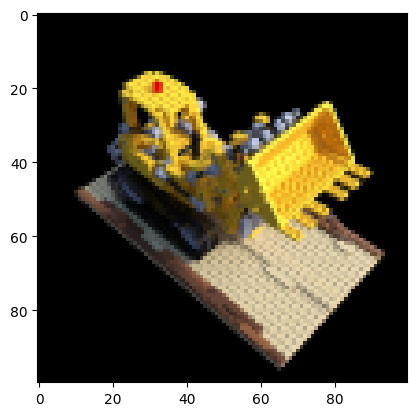

In [24]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)
device = "cuda" if torch.cuda.is_available() else "cpu"

testimg, testpose = images[101], poses[101]
images = images[:100,...,:3]
poses = poses[:100]
plt.imshow(testimg)
plt.show()
testimg =  torch.from_numpy(testimg).float().to(device)
testpose = torch.from_numpy(testpose).float().to(device)

## Train

Using device: cuda
Step 0 | Loss: 0.191380


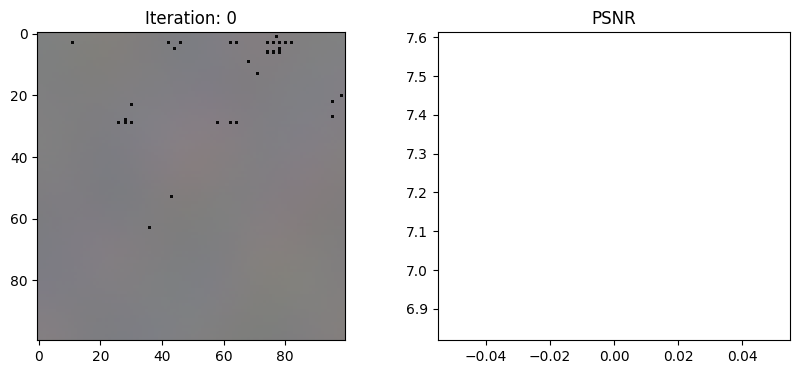

TOTAL STEP TIME taken for iter 0: 1.444183349609375
TOTAL STEP TIME taken for iter 1: 0.3101184368133545
TOTAL STEP TIME taken for iter 2: 0.7903649806976318
TOTAL STEP TIME taken for iter 3: 0.7887864112854004
TOTAL STEP TIME taken for iter 4: 0.7881009578704834
TOTAL STEP TIME taken for iter 5: 0.7913002967834473
TOTAL STEP TIME taken for iter 6: 0.7922565937042236
TOTAL STEP TIME taken for iter 7: 0.7890727519989014
TOTAL STEP TIME taken for iter 8: 0.7889895439147949
TOTAL STEP TIME taken for iter 9: 0.790982723236084
TOTAL STEP TIME taken for iter 10: 0.8050882816314697
TOTAL STEP TIME taken for iter 11: 0.7947144508361816
TOTAL STEP TIME taken for iter 12: 0.7867884635925293
TOTAL STEP TIME taken for iter 13: 0.8052482604980469
TOTAL STEP TIME taken for iter 14: 0.8023016452789307
TOTAL STEP TIME taken for iter 15: 0.8065533638000488
TOTAL STEP TIME taken for iter 16: 0.8072924613952637
TOTAL STEP TIME taken for iter 17: 0.8134775161743164
TOTAL STEP TIME taken for iter 18: 0.804

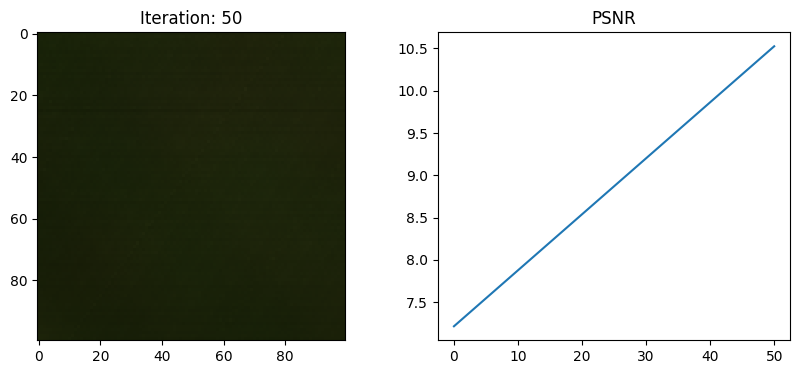

TOTAL STEP TIME taken for iter 50: 1.8715646266937256
TOTAL STEP TIME taken for iter 51: 0.323366641998291
TOTAL STEP TIME taken for iter 52: 0.846454381942749
TOTAL STEP TIME taken for iter 53: 0.8430626392364502
TOTAL STEP TIME taken for iter 54: 0.8401148319244385
TOTAL STEP TIME taken for iter 55: 0.8518698215484619
TOTAL STEP TIME taken for iter 56: 0.8498287200927734
TOTAL STEP TIME taken for iter 57: 0.8590023517608643
TOTAL STEP TIME taken for iter 58: 0.8519141674041748
TOTAL STEP TIME taken for iter 59: 0.8539214134216309
TOTAL STEP TIME taken for iter 60: 0.8532655239105225
TOTAL STEP TIME taken for iter 61: 0.8597662448883057
TOTAL STEP TIME taken for iter 62: 0.8411433696746826
TOTAL STEP TIME taken for iter 63: 0.8612406253814697
TOTAL STEP TIME taken for iter 64: 0.8672473430633545
TOTAL STEP TIME taken for iter 65: 0.8668525218963623
TOTAL STEP TIME taken for iter 66: 0.8644075393676758
TOTAL STEP TIME taken for iter 67: 0.8639569282531738
TOTAL STEP TIME taken for iter

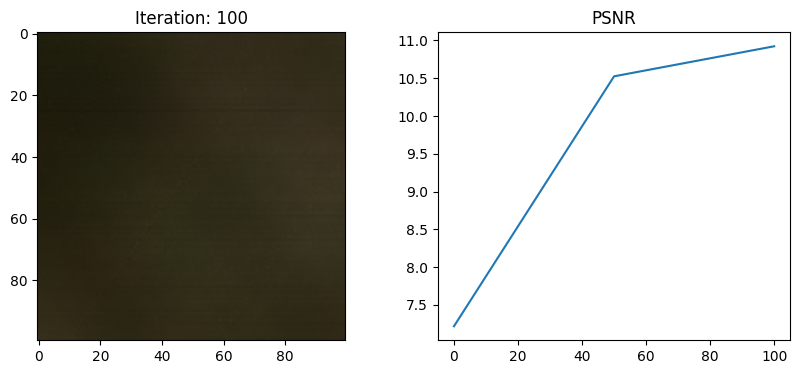

TOTAL STEP TIME taken for iter 100: 1.8984463214874268
TOTAL STEP TIME taken for iter 101: 0.3370492458343506
TOTAL STEP TIME taken for iter 102: 0.8560922145843506
TOTAL STEP TIME taken for iter 103: 0.8545856475830078
TOTAL STEP TIME taken for iter 104: 0.8551437854766846
TOTAL STEP TIME taken for iter 105: 0.8601663112640381
TOTAL STEP TIME taken for iter 106: 0.8627035617828369
TOTAL STEP TIME taken for iter 107: 0.85447096824646
TOTAL STEP TIME taken for iter 108: 0.8543047904968262
TOTAL STEP TIME taken for iter 109: 0.852332592010498
TOTAL STEP TIME taken for iter 110: 0.8549044132232666
TOTAL STEP TIME taken for iter 111: 0.8569655418395996
TOTAL STEP TIME taken for iter 112: 0.8515033721923828
TOTAL STEP TIME taken for iter 113: 0.8498072624206543
TOTAL STEP TIME taken for iter 114: 0.8471214771270752
TOTAL STEP TIME taken for iter 115: 0.8537118434906006
TOTAL STEP TIME taken for iter 116: 0.8518178462982178
TOTAL STEP TIME taken for iter 117: 0.846900463104248
TOTAL STEP TIM

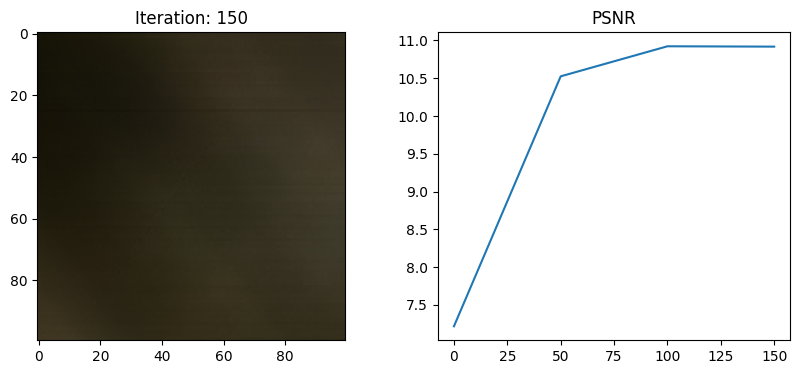

TOTAL STEP TIME taken for iter 150: 1.933802843093872
TOTAL STEP TIME taken for iter 151: 0.3272213935852051
TOTAL STEP TIME taken for iter 152: 0.8665683269500732
TOTAL STEP TIME taken for iter 153: 0.8576529026031494
TOTAL STEP TIME taken for iter 154: 0.8633043766021729
TOTAL STEP TIME taken for iter 155: 0.8580079078674316
TOTAL STEP TIME taken for iter 156: 0.8613333702087402
TOTAL STEP TIME taken for iter 157: 0.8573386669158936
TOTAL STEP TIME taken for iter 158: 0.8618454933166504
TOTAL STEP TIME taken for iter 159: 0.8621501922607422
TOTAL STEP TIME taken for iter 160: 0.8706037998199463
TOTAL STEP TIME taken for iter 161: 0.8661212921142578
TOTAL STEP TIME taken for iter 162: 0.870100736618042
TOTAL STEP TIME taken for iter 163: 0.8685464859008789
TOTAL STEP TIME taken for iter 164: 0.8709290027618408
TOTAL STEP TIME taken for iter 165: 0.8703081607818604
TOTAL STEP TIME taken for iter 166: 0.8755409717559814
TOTAL STEP TIME taken for iter 167: 0.8647866249084473
TOTAL STEP T

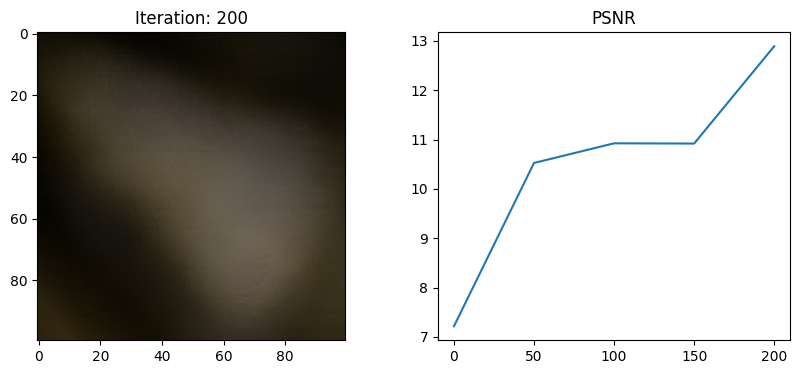

TOTAL STEP TIME taken for iter 200: 2.006850004196167
TOTAL STEP TIME taken for iter 201: 0.33690905570983887
TOTAL STEP TIME taken for iter 202: 0.8581802845001221
TOTAL STEP TIME taken for iter 203: 0.8506271839141846
TOTAL STEP TIME taken for iter 204: 0.8464288711547852
TOTAL STEP TIME taken for iter 205: 0.8513591289520264
TOTAL STEP TIME taken for iter 206: 0.8506858348846436
TOTAL STEP TIME taken for iter 207: 0.8504605293273926
TOTAL STEP TIME taken for iter 208: 0.8517334461212158
TOTAL STEP TIME taken for iter 209: 0.8490843772888184
TOTAL STEP TIME taken for iter 210: 0.8536891937255859
TOTAL STEP TIME taken for iter 211: 0.8502192497253418
TOTAL STEP TIME taken for iter 212: 0.8440535068511963
TOTAL STEP TIME taken for iter 213: 0.8510386943817139
TOTAL STEP TIME taken for iter 214: 0.8507647514343262
TOTAL STEP TIME taken for iter 215: 0.8489837646484375
TOTAL STEP TIME taken for iter 216: 0.8393354415893555
TOTAL STEP TIME taken for iter 217: 0.8655490875244141
TOTAL STEP

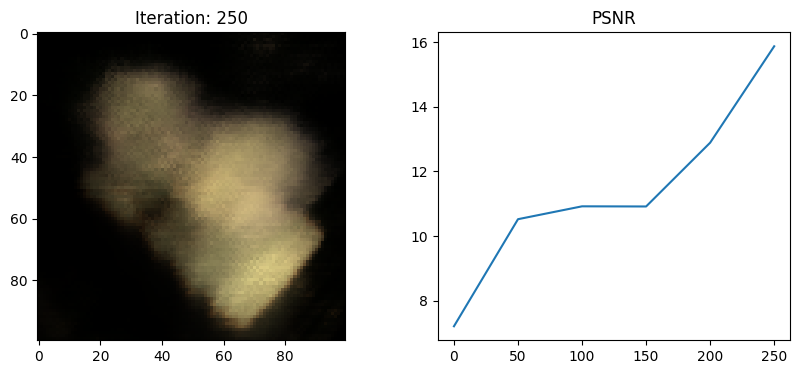

TOTAL STEP TIME taken for iter 250: 1.852449893951416
TOTAL STEP TIME taken for iter 251: 0.33064913749694824
TOTAL STEP TIME taken for iter 252: 0.8496885299682617
TOTAL STEP TIME taken for iter 253: 0.8405811786651611
TOTAL STEP TIME taken for iter 254: 0.8439652919769287
TOTAL STEP TIME taken for iter 255: 0.8428652286529541
TOTAL STEP TIME taken for iter 256: 0.8330683708190918
TOTAL STEP TIME taken for iter 257: 0.8330807685852051
TOTAL STEP TIME taken for iter 258: 0.8311958312988281
TOTAL STEP TIME taken for iter 259: 0.8317909240722656
TOTAL STEP TIME taken for iter 260: 0.8268125057220459
TOTAL STEP TIME taken for iter 261: 0.8316347599029541
TOTAL STEP TIME taken for iter 262: 0.8253152370452881
TOTAL STEP TIME taken for iter 263: 0.8265995979309082
TOTAL STEP TIME taken for iter 264: 0.8278565406799316
TOTAL STEP TIME taken for iter 265: 0.8294827938079834
TOTAL STEP TIME taken for iter 266: 0.8316912651062012
TOTAL STEP TIME taken for iter 267: 0.8310401439666748
TOTAL STEP

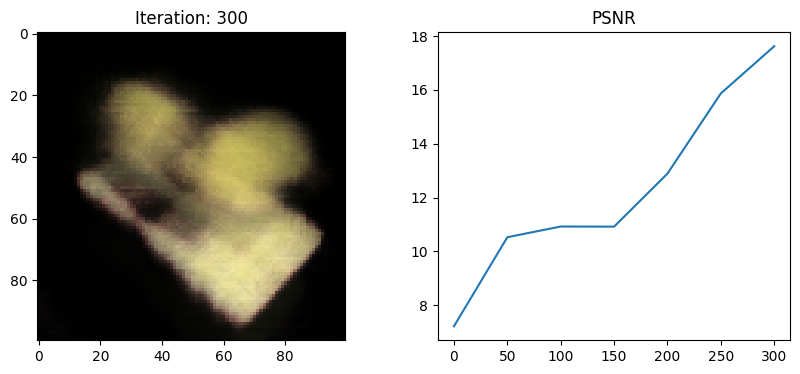

TOTAL STEP TIME taken for iter 300: 1.84039306640625
TOTAL STEP TIME taken for iter 301: 0.33275938034057617
TOTAL STEP TIME taken for iter 302: 0.824164628982544
TOTAL STEP TIME taken for iter 303: 0.8403820991516113
TOTAL STEP TIME taken for iter 304: 0.8244180679321289
TOTAL STEP TIME taken for iter 305: 0.8261737823486328
TOTAL STEP TIME taken for iter 306: 0.8210945129394531
TOTAL STEP TIME taken for iter 307: 0.8262670040130615
TOTAL STEP TIME taken for iter 308: 0.8239750862121582
TOTAL STEP TIME taken for iter 309: 0.8301613330841064
TOTAL STEP TIME taken for iter 310: 0.8372659683227539
TOTAL STEP TIME taken for iter 311: 0.8145897388458252
TOTAL STEP TIME taken for iter 312: 0.8312530517578125
TOTAL STEP TIME taken for iter 313: 0.8291003704071045
TOTAL STEP TIME taken for iter 314: 0.8265261650085449
TOTAL STEP TIME taken for iter 315: 0.8299548625946045
TOTAL STEP TIME taken for iter 316: 0.8283529281616211
TOTAL STEP TIME taken for iter 317: 0.8227748870849609
TOTAL STEP T

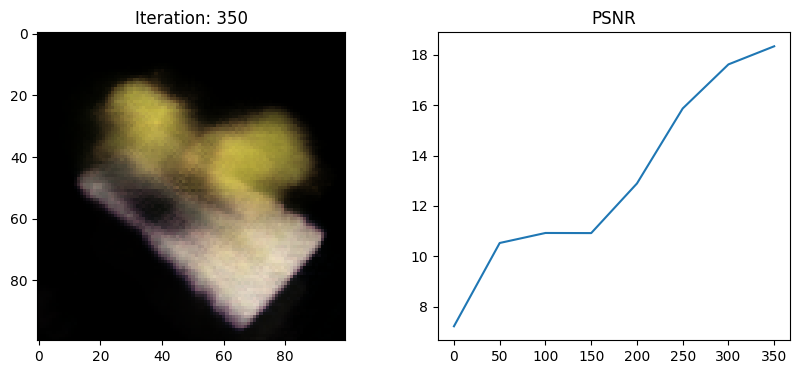

TOTAL STEP TIME taken for iter 350: 1.842939853668213
TOTAL STEP TIME taken for iter 351: 0.3312265872955322
TOTAL STEP TIME taken for iter 352: 0.812701940536499
TOTAL STEP TIME taken for iter 353: 0.8284423351287842
TOTAL STEP TIME taken for iter 354: 0.8269443511962891
TOTAL STEP TIME taken for iter 355: 0.8221042156219482
TOTAL STEP TIME taken for iter 356: 0.8290681838989258
TOTAL STEP TIME taken for iter 357: 0.8234951496124268
TOTAL STEP TIME taken for iter 358: 0.8303563594818115
TOTAL STEP TIME taken for iter 359: 0.8278017044067383
TOTAL STEP TIME taken for iter 360: 0.8301105499267578
TOTAL STEP TIME taken for iter 361: 0.8289780616760254
TOTAL STEP TIME taken for iter 362: 0.8343625068664551
TOTAL STEP TIME taken for iter 363: 0.8259057998657227
TOTAL STEP TIME taken for iter 364: 0.8299026489257812
TOTAL STEP TIME taken for iter 365: 0.8253991603851318
TOTAL STEP TIME taken for iter 366: 0.8297302722930908
TOTAL STEP TIME taken for iter 367: 0.8387298583984375
TOTAL STEP T

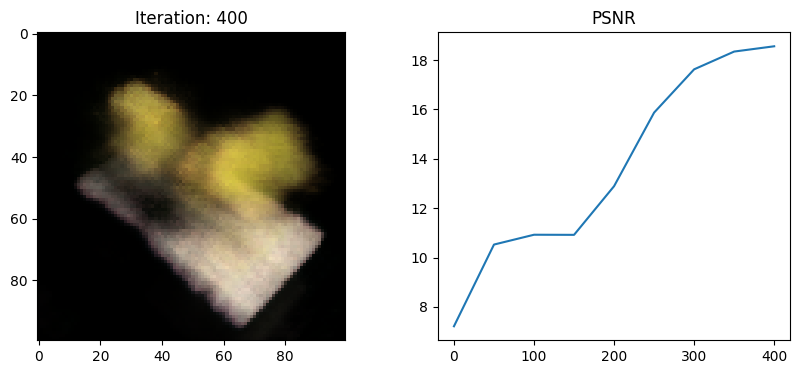

TOTAL STEP TIME taken for iter 400: 1.8419418334960938
TOTAL STEP TIME taken for iter 401: 0.32962751388549805
TOTAL STEP TIME taken for iter 402: 0.8182759284973145
TOTAL STEP TIME taken for iter 403: 0.823521614074707
TOTAL STEP TIME taken for iter 404: 0.8231680393218994
TOTAL STEP TIME taken for iter 405: 0.8207025527954102
TOTAL STEP TIME taken for iter 406: 0.828819751739502
TOTAL STEP TIME taken for iter 407: 0.8310472965240479
TOTAL STEP TIME taken for iter 408: 0.8218362331390381
TOTAL STEP TIME taken for iter 409: 0.8242743015289307
TOTAL STEP TIME taken for iter 410: 0.8144285678863525
TOTAL STEP TIME taken for iter 411: 0.8235538005828857
TOTAL STEP TIME taken for iter 412: 0.824134349822998
TOTAL STEP TIME taken for iter 413: 0.823183536529541
TOTAL STEP TIME taken for iter 414: 0.8140826225280762
TOTAL STEP TIME taken for iter 415: 0.8307867050170898
TOTAL STEP TIME taken for iter 416: 0.828542947769165
TOTAL STEP TIME taken for iter 417: 0.8261442184448242
TOTAL STEP TIM

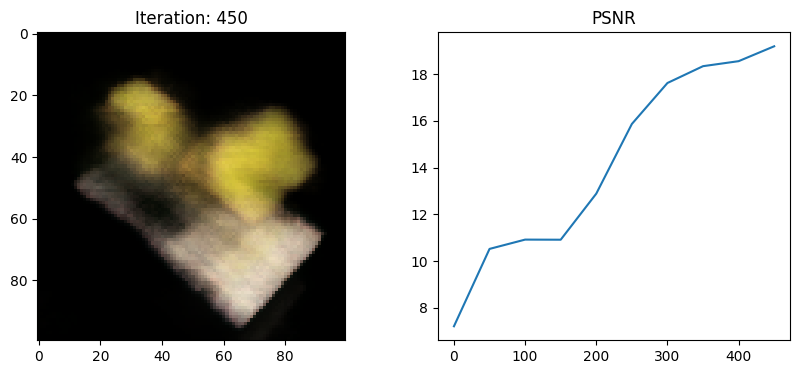

TOTAL STEP TIME taken for iter 450: 1.8165247440338135
TOTAL STEP TIME taken for iter 451: 0.3322303295135498
TOTAL STEP TIME taken for iter 452: 0.8231790065765381
TOTAL STEP TIME taken for iter 453: 0.8187870979309082
TOTAL STEP TIME taken for iter 454: 0.8317561149597168
TOTAL STEP TIME taken for iter 455: 0.8102753162384033
TOTAL STEP TIME taken for iter 456: 0.8279099464416504
TOTAL STEP TIME taken for iter 457: 0.8258070945739746
TOTAL STEP TIME taken for iter 458: 0.82200026512146
TOTAL STEP TIME taken for iter 459: 0.8250749111175537
TOTAL STEP TIME taken for iter 460: 0.8247272968292236
TOTAL STEP TIME taken for iter 461: 0.8166396617889404
TOTAL STEP TIME taken for iter 462: 0.830286979675293
TOTAL STEP TIME taken for iter 463: 0.8259570598602295
TOTAL STEP TIME taken for iter 464: 0.8147518634796143
TOTAL STEP TIME taken for iter 465: 0.8230581283569336
TOTAL STEP TIME taken for iter 466: 0.8189480304718018
TOTAL STEP TIME taken for iter 467: 0.831536054611206
TOTAL STEP TIM

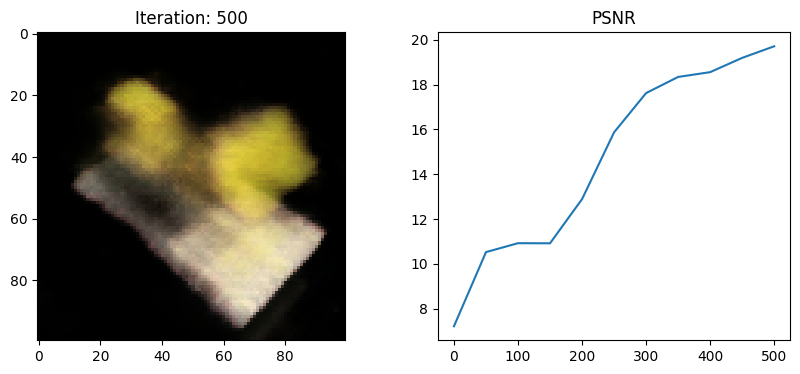

TOTAL STEP TIME taken for iter 500: 1.8242292404174805
TOTAL STEP TIME taken for iter 501: 0.3314208984375
TOTAL STEP TIME taken for iter 502: 0.8117961883544922
TOTAL STEP TIME taken for iter 503: 0.8155298233032227
TOTAL STEP TIME taken for iter 504: 0.8161227703094482
TOTAL STEP TIME taken for iter 505: 0.818096399307251
TOTAL STEP TIME taken for iter 506: 0.8305110931396484
TOTAL STEP TIME taken for iter 507: 0.8203256130218506
TOTAL STEP TIME taken for iter 508: 0.8183016777038574
TOTAL STEP TIME taken for iter 509: 0.8242461681365967
TOTAL STEP TIME taken for iter 510: 0.818976640701294
TOTAL STEP TIME taken for iter 511: 0.8202557563781738
TOTAL STEP TIME taken for iter 512: 0.8140699863433838
TOTAL STEP TIME taken for iter 513: 0.8251926898956299
TOTAL STEP TIME taken for iter 514: 0.8133256435394287
TOTAL STEP TIME taken for iter 515: 0.8079352378845215
TOTAL STEP TIME taken for iter 516: 0.8174350261688232
TOTAL STEP TIME taken for iter 517: 0.8166613578796387
TOTAL STEP TIME

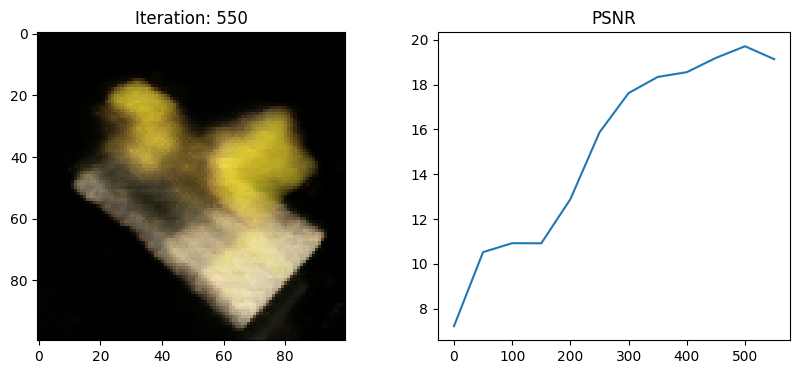

TOTAL STEP TIME taken for iter 550: 1.8183839321136475
TOTAL STEP TIME taken for iter 551: 0.33275818824768066
TOTAL STEP TIME taken for iter 552: 0.811237096786499
TOTAL STEP TIME taken for iter 553: 0.8116786479949951
TOTAL STEP TIME taken for iter 554: 0.8295004367828369
TOTAL STEP TIME taken for iter 555: 0.8262848854064941
TOTAL STEP TIME taken for iter 556: 0.8113296031951904
TOTAL STEP TIME taken for iter 557: 0.8118491172790527
TOTAL STEP TIME taken for iter 558: 0.8188140392303467
TOTAL STEP TIME taken for iter 559: 0.8278944492340088
TOTAL STEP TIME taken for iter 560: 0.8190591335296631
TOTAL STEP TIME taken for iter 561: 0.8186285495758057
TOTAL STEP TIME taken for iter 562: 0.8199431896209717
TOTAL STEP TIME taken for iter 563: 0.8182790279388428
TOTAL STEP TIME taken for iter 564: 0.8339815139770508
TOTAL STEP TIME taken for iter 565: 0.8145613670349121
TOTAL STEP TIME taken for iter 566: 0.8206896781921387
TOTAL STEP TIME taken for iter 567: 0.8188741207122803
TOTAL STEP

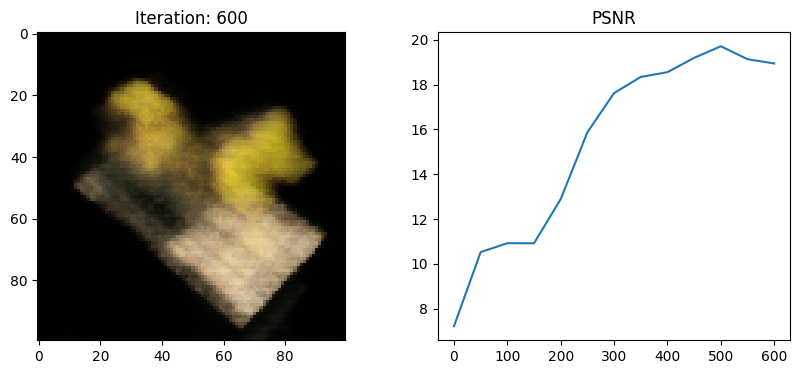

TOTAL STEP TIME taken for iter 600: 1.8105640411376953
TOTAL STEP TIME taken for iter 601: 0.33801913261413574
TOTAL STEP TIME taken for iter 602: 0.8070948123931885
TOTAL STEP TIME taken for iter 603: 0.8143079280853271
TOTAL STEP TIME taken for iter 604: 0.8208291530609131
TOTAL STEP TIME taken for iter 605: 0.8144598007202148
TOTAL STEP TIME taken for iter 606: 0.8137764930725098
TOTAL STEP TIME taken for iter 607: 0.8207340240478516
TOTAL STEP TIME taken for iter 608: 0.8192665576934814
TOTAL STEP TIME taken for iter 609: 0.8305130004882812
TOTAL STEP TIME taken for iter 610: 0.8299534320831299
TOTAL STEP TIME taken for iter 611: 0.8203277587890625
TOTAL STEP TIME taken for iter 612: 0.8212430477142334
TOTAL STEP TIME taken for iter 613: 0.8215789794921875
TOTAL STEP TIME taken for iter 614: 0.8188226222991943
TOTAL STEP TIME taken for iter 615: 0.8208713531494141
TOTAL STEP TIME taken for iter 616: 0.8216762542724609
TOTAL STEP TIME taken for iter 617: 0.8208940029144287
TOTAL STE

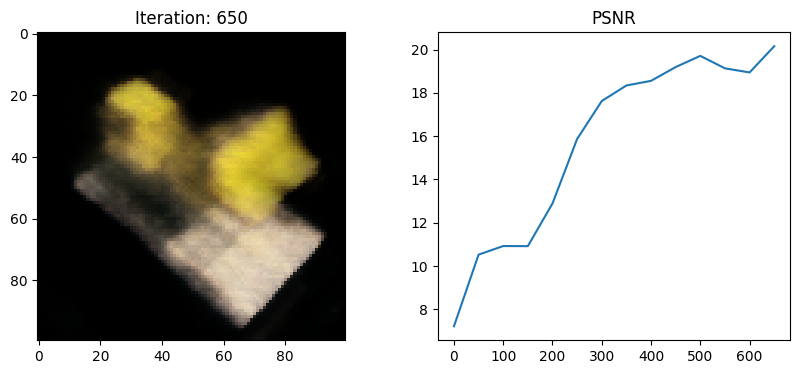

TOTAL STEP TIME taken for iter 650: 1.8133957386016846
TOTAL STEP TIME taken for iter 651: 0.3308851718902588
TOTAL STEP TIME taken for iter 652: 0.8232686519622803
TOTAL STEP TIME taken for iter 653: 0.8294754028320312
TOTAL STEP TIME taken for iter 654: 0.8240528106689453
TOTAL STEP TIME taken for iter 655: 0.8162314891815186
TOTAL STEP TIME taken for iter 656: 0.8231909275054932
TOTAL STEP TIME taken for iter 657: 0.8095545768737793
TOTAL STEP TIME taken for iter 658: 0.8123700618743896
TOTAL STEP TIME taken for iter 659: 0.8106553554534912
TOTAL STEP TIME taken for iter 660: 0.8191938400268555
TOTAL STEP TIME taken for iter 661: 0.8197104930877686
TOTAL STEP TIME taken for iter 662: 0.8334195613861084
TOTAL STEP TIME taken for iter 663: 0.8278219699859619
TOTAL STEP TIME taken for iter 664: 0.8076596260070801
TOTAL STEP TIME taken for iter 665: 0.8236227035522461
TOTAL STEP TIME taken for iter 666: 0.8123257160186768
TOTAL STEP TIME taken for iter 667: 0.8132481575012207
TOTAL STEP

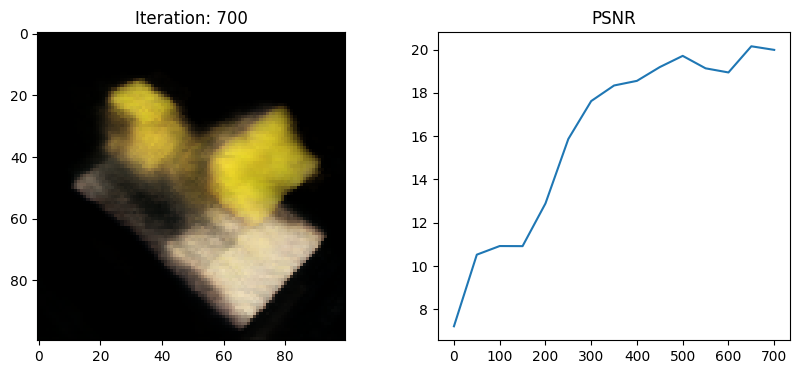

TOTAL STEP TIME taken for iter 700: 1.813765287399292
TOTAL STEP TIME taken for iter 701: 0.3287012577056885
TOTAL STEP TIME taken for iter 702: 0.8100273609161377
TOTAL STEP TIME taken for iter 703: 0.8114912509918213
TOTAL STEP TIME taken for iter 704: 0.8097062110900879
TOTAL STEP TIME taken for iter 705: 0.8135521411895752
TOTAL STEP TIME taken for iter 706: 0.8132050037384033
TOTAL STEP TIME taken for iter 707: 0.8139231204986572
TOTAL STEP TIME taken for iter 708: 0.8093810081481934
TOTAL STEP TIME taken for iter 709: 0.8120677471160889
TOTAL STEP TIME taken for iter 710: 0.7985246181488037
TOTAL STEP TIME taken for iter 711: 0.8163940906524658
TOTAL STEP TIME taken for iter 712: 0.8127133846282959
TOTAL STEP TIME taken for iter 713: 0.8096275329589844
TOTAL STEP TIME taken for iter 714: 0.8108053207397461
TOTAL STEP TIME taken for iter 715: 0.8159401416778564
TOTAL STEP TIME taken for iter 716: 0.8181114196777344
TOTAL STEP TIME taken for iter 717: 0.814887285232544
TOTAL STEP T

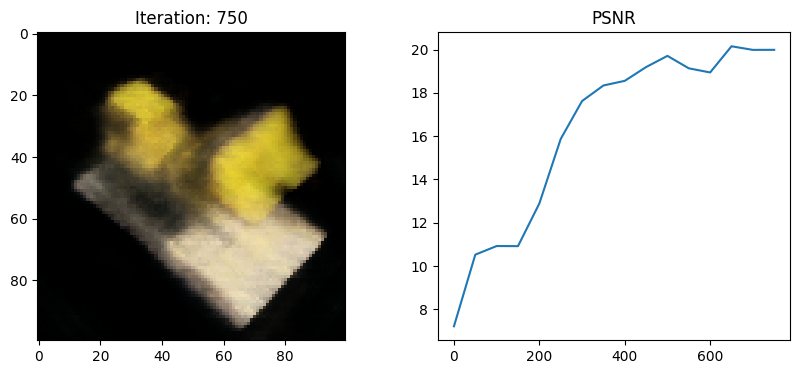

TOTAL STEP TIME taken for iter 750: 1.9758379459381104
TOTAL STEP TIME taken for iter 751: 0.3277592658996582
TOTAL STEP TIME taken for iter 752: 0.8148577213287354
TOTAL STEP TIME taken for iter 753: 0.8061003684997559
TOTAL STEP TIME taken for iter 754: 0.8087871074676514
TOTAL STEP TIME taken for iter 755: 0.8034219741821289
TOTAL STEP TIME taken for iter 756: 0.8103013038635254
TOTAL STEP TIME taken for iter 757: 0.8150718212127686
TOTAL STEP TIME taken for iter 758: 0.8036839962005615
TOTAL STEP TIME taken for iter 759: 0.8089289665222168
TOTAL STEP TIME taken for iter 760: 0.8130795955657959
TOTAL STEP TIME taken for iter 761: 0.8076028823852539
TOTAL STEP TIME taken for iter 762: 0.8109138011932373
TOTAL STEP TIME taken for iter 763: 0.8051788806915283
TOTAL STEP TIME taken for iter 764: 0.8030967712402344
TOTAL STEP TIME taken for iter 765: 0.8021864891052246
TOTAL STEP TIME taken for iter 766: 0.8080215454101562
TOTAL STEP TIME taken for iter 767: 0.8122823238372803
TOTAL STEP

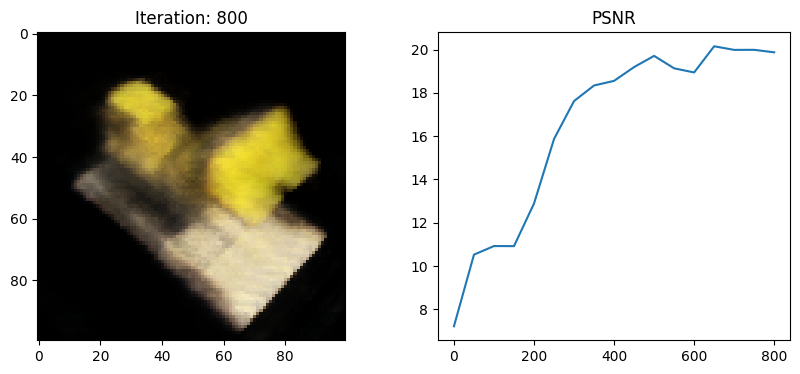

TOTAL STEP TIME taken for iter 800: 1.7960700988769531
TOTAL STEP TIME taken for iter 801: 0.32901763916015625
TOTAL STEP TIME taken for iter 802: 0.8141908645629883
TOTAL STEP TIME taken for iter 803: 0.8118410110473633
TOTAL STEP TIME taken for iter 804: 0.8049335479736328
TOTAL STEP TIME taken for iter 805: 0.8050427436828613
TOTAL STEP TIME taken for iter 806: 0.8143706321716309
TOTAL STEP TIME taken for iter 807: 0.8088302612304688
TOTAL STEP TIME taken for iter 808: 0.8162665367126465
TOTAL STEP TIME taken for iter 809: 0.8058295249938965
TOTAL STEP TIME taken for iter 810: 0.8048412799835205
TOTAL STEP TIME taken for iter 811: 0.8152270317077637
TOTAL STEP TIME taken for iter 812: 0.8088014125823975
TOTAL STEP TIME taken for iter 813: 0.8128702640533447
TOTAL STEP TIME taken for iter 814: 0.8069930076599121
TOTAL STEP TIME taken for iter 815: 0.8161664009094238
TOTAL STEP TIME taken for iter 816: 0.804694652557373
TOTAL STEP TIME taken for iter 817: 0.8081636428833008
TOTAL STEP

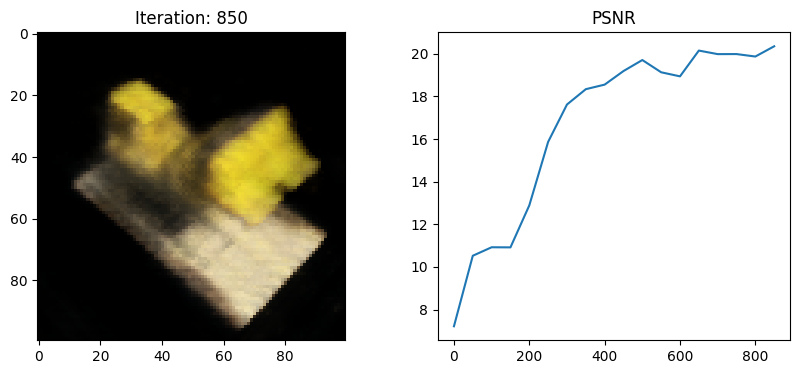

TOTAL STEP TIME taken for iter 850: 1.8005855083465576
TOTAL STEP TIME taken for iter 851: 0.32761478424072266
TOTAL STEP TIME taken for iter 852: 0.8077671527862549
TOTAL STEP TIME taken for iter 853: 0.818556547164917
TOTAL STEP TIME taken for iter 854: 0.8131780624389648
TOTAL STEP TIME taken for iter 855: 0.8027994632720947
TOTAL STEP TIME taken for iter 856: 0.8125951290130615
TOTAL STEP TIME taken for iter 857: 0.8018577098846436
TOTAL STEP TIME taken for iter 858: 0.8067789077758789
TOTAL STEP TIME taken for iter 859: 0.8047144412994385
TOTAL STEP TIME taken for iter 860: 0.8137729167938232
TOTAL STEP TIME taken for iter 861: 0.815298318862915
TOTAL STEP TIME taken for iter 862: 0.8043923377990723
TOTAL STEP TIME taken for iter 863: 0.8110682964324951
TOTAL STEP TIME taken for iter 864: 0.8104727268218994
TOTAL STEP TIME taken for iter 865: 0.8159325122833252
TOTAL STEP TIME taken for iter 866: 0.8076057434082031
TOTAL STEP TIME taken for iter 867: 0.8086879253387451
TOTAL STEP 

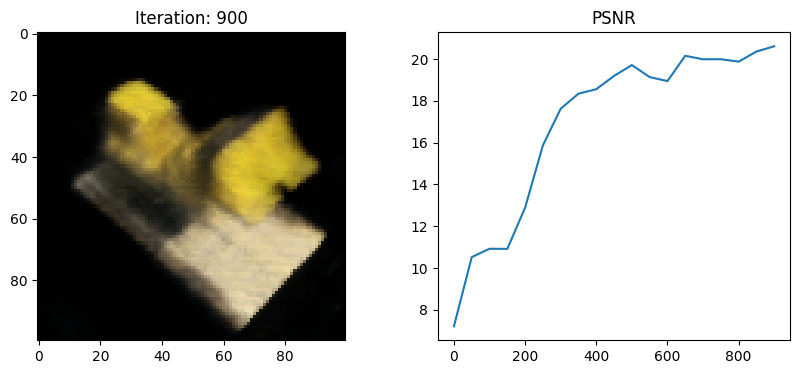

TOTAL STEP TIME taken for iter 900: 1.802525520324707
TOTAL STEP TIME taken for iter 901: 0.32842445373535156
TOTAL STEP TIME taken for iter 902: 0.8016421794891357
TOTAL STEP TIME taken for iter 903: 0.8085403442382812
TOTAL STEP TIME taken for iter 904: 0.8240129947662354
TOTAL STEP TIME taken for iter 905: 0.810023307800293
TOTAL STEP TIME taken for iter 906: 0.8255107402801514
TOTAL STEP TIME taken for iter 907: 0.8092551231384277
TOTAL STEP TIME taken for iter 908: 0.8024470806121826
TOTAL STEP TIME taken for iter 909: 0.8075947761535645
TOTAL STEP TIME taken for iter 910: 0.8198375701904297
TOTAL STEP TIME taken for iter 911: 0.8077554702758789
TOTAL STEP TIME taken for iter 912: 0.805511474609375
TOTAL STEP TIME taken for iter 913: 0.8067491054534912
TOTAL STEP TIME taken for iter 914: 0.810544490814209
TOTAL STEP TIME taken for iter 915: 0.8092479705810547
TOTAL STEP TIME taken for iter 916: 0.8117885589599609
TOTAL STEP TIME taken for iter 917: 0.8100700378417969
TOTAL STEP TI

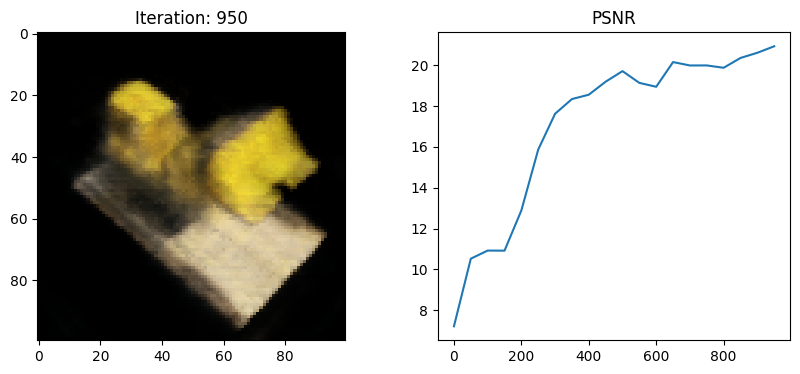

TOTAL STEP TIME taken for iter 950: 1.878488302230835
TOTAL STEP TIME taken for iter 951: 0.33048391342163086
TOTAL STEP TIME taken for iter 952: 0.8049976825714111
TOTAL STEP TIME taken for iter 953: 0.8045530319213867
TOTAL STEP TIME taken for iter 954: 0.808546781539917
TOTAL STEP TIME taken for iter 955: 0.813929557800293
TOTAL STEP TIME taken for iter 956: 0.8087742328643799
TOTAL STEP TIME taken for iter 957: 0.8082075119018555
TOTAL STEP TIME taken for iter 958: 0.8159074783325195
TOTAL STEP TIME taken for iter 959: 0.8115818500518799
TOTAL STEP TIME taken for iter 960: 0.8113031387329102
TOTAL STEP TIME taken for iter 961: 0.8115189075469971
TOTAL STEP TIME taken for iter 962: 0.810309886932373
TOTAL STEP TIME taken for iter 963: 0.8071863651275635
TOTAL STEP TIME taken for iter 964: 0.8029778003692627
TOTAL STEP TIME taken for iter 965: 0.8189096450805664
TOTAL STEP TIME taken for iter 966: 0.8068897724151611
TOTAL STEP TIME taken for iter 967: 0.8129885196685791
TOTAL STEP TI

In [25]:
model = train(images,poses,H,W,focal,testpose,testimg,device)

## Render Video

In [26]:
# Transformation matrices in PyTorch
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi), torch.cos(phi), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0, torch.cos(th), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

# Pose function with spherical coordinates
def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = torch.matmul(rot_phi(torch.Tensor([phi / 180. * np.pi])), c2w)
    c2w = torch.matmul(rot_theta(torch.Tensor([theta / 180. * np.pi])), c2w)
    c2w = torch.tensor([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=torch.float32) @ c2w
    return c2w

# Function for rendering based on user input
def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])  # Get rays (this is a placeholder)
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device=device)  # Render rays
    rgb = rgb.reshape(H, W, 3).cpu().detach()
    img = torch.clamp(rgb, 0, 1).numpy()  # Clamp RGB values between 0 and 1 and convert to numpy

    plt.figure(2, figsize=(20, 6))
    plt.imshow(img)
    plt.show()

# Interactive slider setup for theta, phi, and radius
sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [27]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device = device)
    rgb = rgb.reshape(H, W, 3)
    frames.append((255*np.clip(rgb.cpu().detach().numpy(),0,1)).astype(np.uint8))

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

100%|██████████| 120/120 [00:39<00:00,  3.02it/s]


In [28]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)